In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [8]:
# 사용자 선택: 피크 탐지 모드
# "neg"  -> 음의 피크만 (Abs. Peak Mag. 분석)
# "pos"  -> 양의 피크만 (Abs. Peak Mag. 분석)
# "both" -> 양/음 피크 모두 (pp 분석)
peak_mode = "pos"

detection_mode = "voltage"  # "voltage" or "current"

# -------------------------------
# 폴더 경로
folder_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. [Lead] ionic DC-TENG\0. 실험자료\8. Gibeom touch\260511_0M CR 이상한 피크 분석\0minimized_csv파일"

# 사용자 설정값
prominence_ratio = 0.3   # 표준편차(std) * 비율로 prominence 기준 설정
min_prominence = 0.10    # prominence 하한
min_distance_sec = 0.05   # 인접 피크 최소 간격(초)
snr_threshold = 1.5      # SNR 기준
min_relative_height = 0.3  # 전체 최대 진폭 대비 최소 비율
abs_min_height = 0.01      # 최소 피크 height

window_peaks = 10       # 연속 피크 개수

# 그래프 Y축
y_range = (None, None)
# y_range = (-0.2, 0.1)

current_scale = 20  # only with current raw data | ex) 10 = 10 μA/V

# CSV 읽기 옵션
voltage_skiprows = 0
current_skiprows = 0

# csv파일 저장
save_summary_csv = False  # False 로 하면 CSV 저장 안 함
# save_summary_csv = True


0.1Hz0_Peak value: 5.96 V
0.1Hz0_Peak number: 1개
0.1Hz0_표준편차: 0.00 V
0.1Hz0_주파수: 0.00 Hz


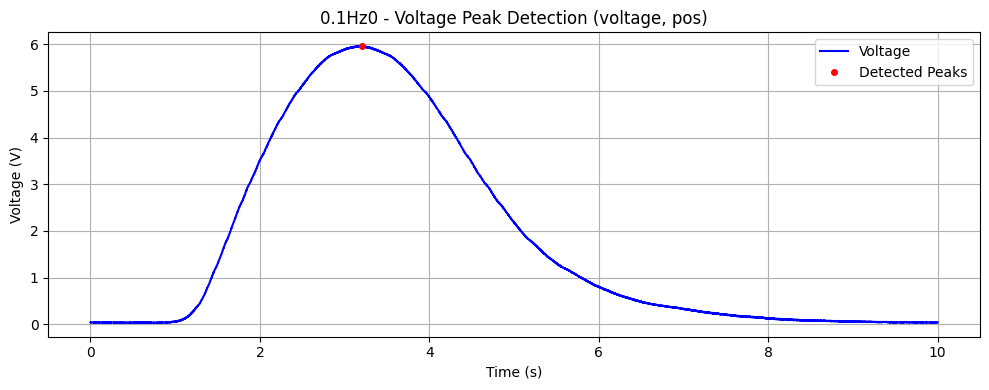

0.1Hz1_Peak value: 5.97 V
0.1Hz1_Peak number: 1개
0.1Hz1_표준편차: 0.00 V
0.1Hz1_주파수: 0.00 Hz


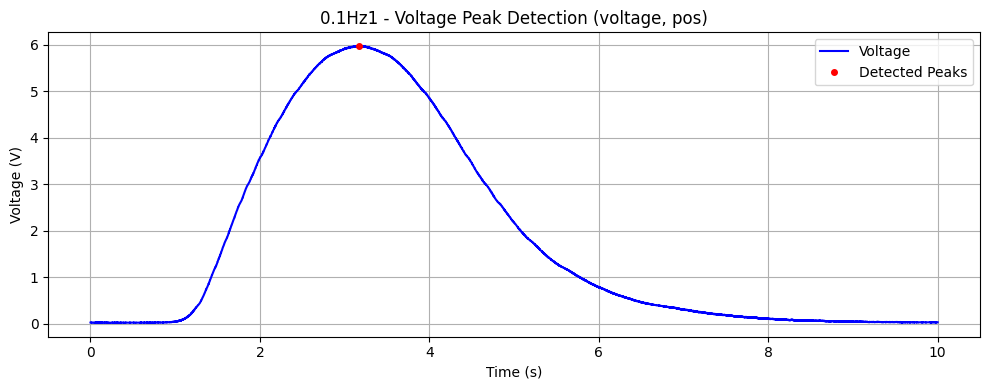

10Hz0_Peak value: 4.97 V
10Hz0_Peak number: 39개
10Hz0_표준편차: 0.00 V
10Hz0_주파수: 10.00 Hz
👉 10Hz0 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 49.71 V
   - 발췌 평균 Peak value: 4.97 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 10.00 Hz


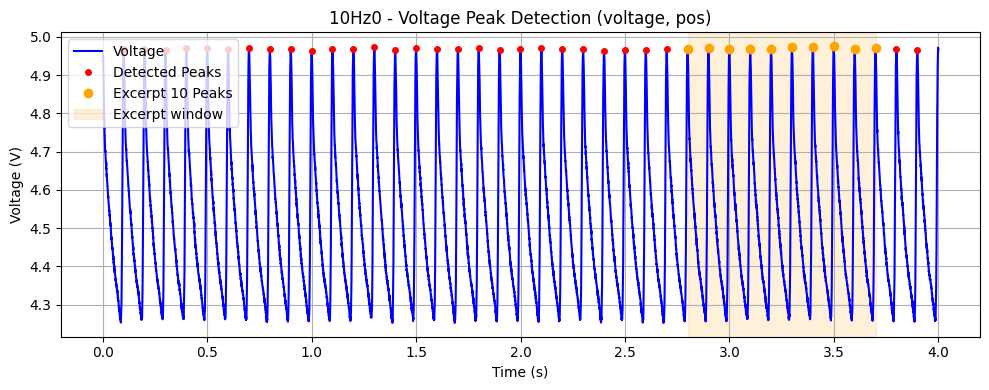

10Hz1_Peak value: 4.97 V
10Hz1_Peak number: 40개
10Hz1_표준편차: 0.00 V
10Hz1_주파수: 10.00 Hz
👉 10Hz1 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 49.67 V
   - 발췌 평균 Peak value: 4.97 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 9.99 Hz


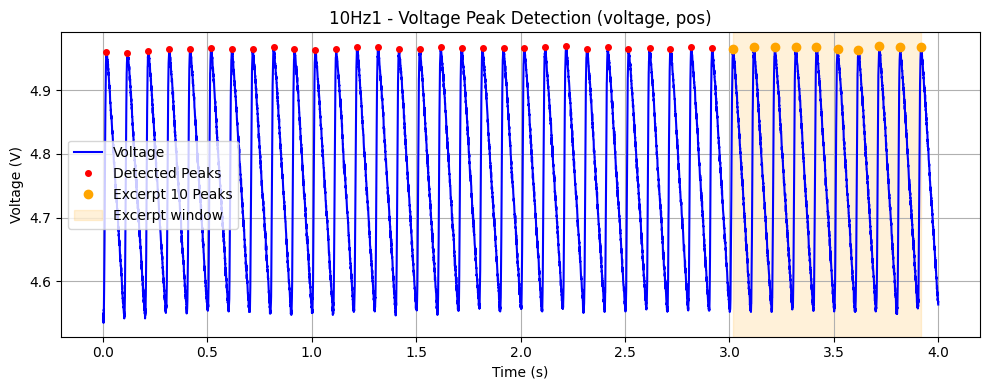

1Hz0_Peak value: 5.53 V
1Hz0_Peak number: 4개
1Hz0_표준편차: 0.00 V
1Hz0_주파수: 1.00 Hz


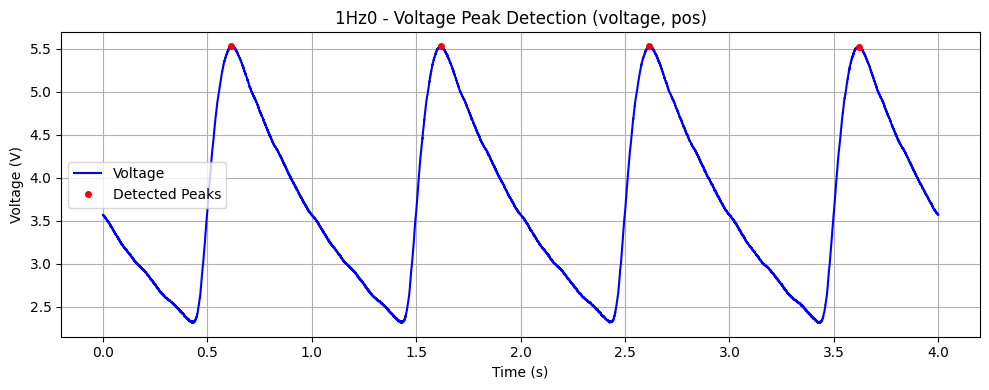

1Hz1_Peak value: 5.63 V
1Hz1_Peak number: 4개
1Hz1_표준편차: 0.00 V
1Hz1_주파수: 1.00 Hz


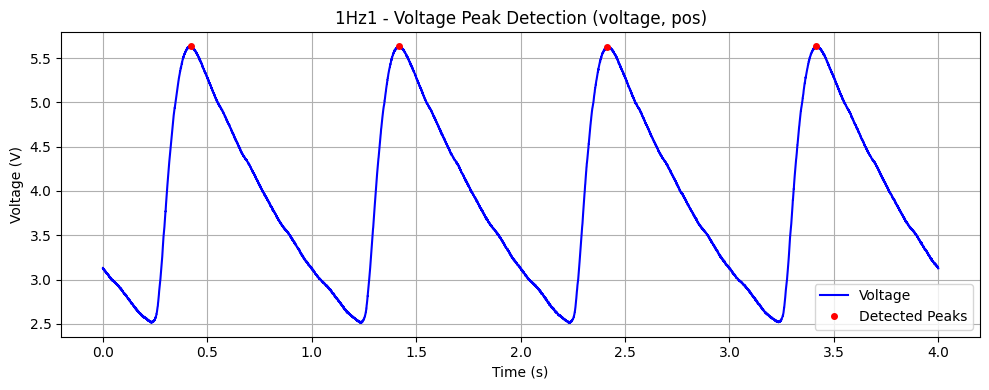

4Hz0_Peak value: 5.10 V
4Hz0_Peak number: 16개
4Hz0_표준편차: 0.00 V
4Hz0_주파수: 4.00 Hz
👉 4Hz0 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 50.99 V
   - 발췌 평균 Peak value: 5.10 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 4.00 Hz


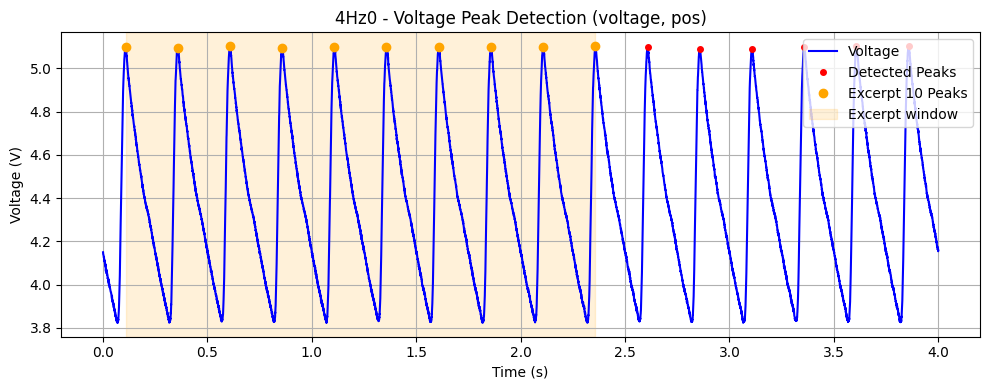

4Hz1_Peak value: 5.18 V
4Hz1_Peak number: 16개
4Hz1_표준편차: 0.00 V
4Hz1_주파수: 4.00 Hz
👉 4Hz1 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 51.83 V
   - 발췌 평균 Peak value: 5.18 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 4.00 Hz


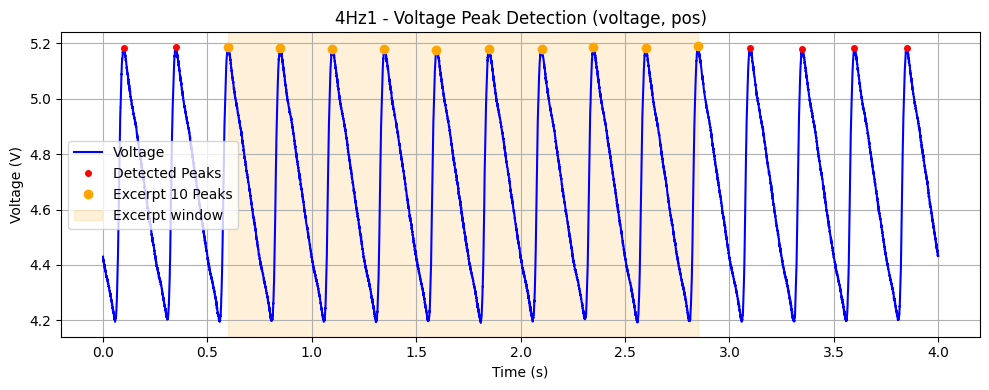

AC-Arb_Peak value: 9.79 V
AC-Arb_Peak number: 16개
AC-Arb_표준편차: 0.00 V
AC-Arb_주파수: 4.00 Hz
👉 AC-Arb 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 97.89 V
   - 발췌 평균 Peak value: 9.79 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 4.00 Hz


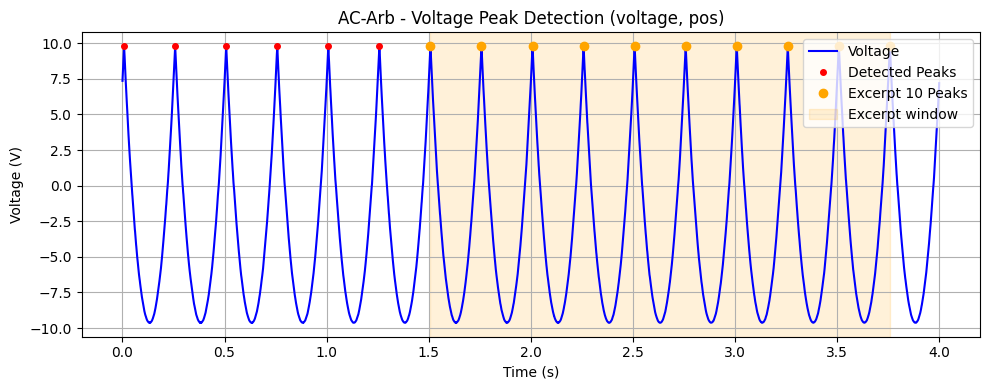

AC-Sin_Peak value: 9.99 V
AC-Sin_Peak number: 40개
AC-Sin_표준편차: 0.00 V
AC-Sin_주파수: 4.00 Hz
👉 AC-Sin 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 99.89 V
   - 발췌 평균 Peak value: 9.99 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 4.00 Hz


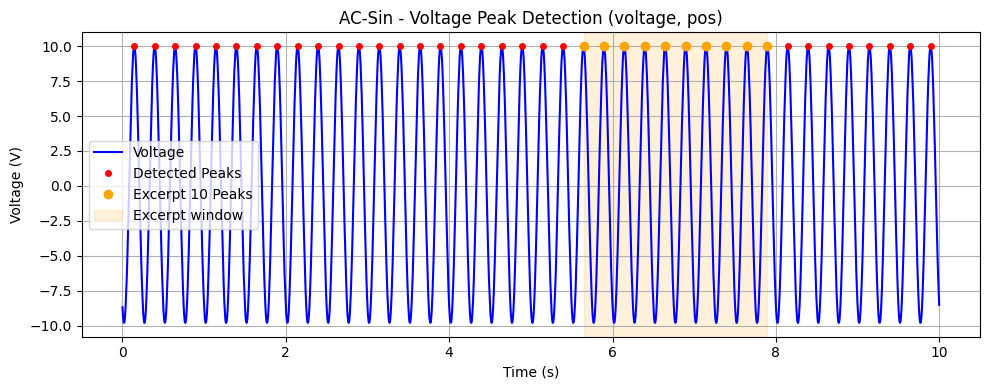

Arb10Hz0_Peak value: 4.36 V
Arb10Hz0_Peak number: 40개
Arb10Hz0_표준편차: 0.00 V
Arb10Hz0_주파수: 10.00 Hz
👉 Arb10Hz0 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 43.67 V
   - 발췌 평균 Peak value: 4.37 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 10.00 Hz


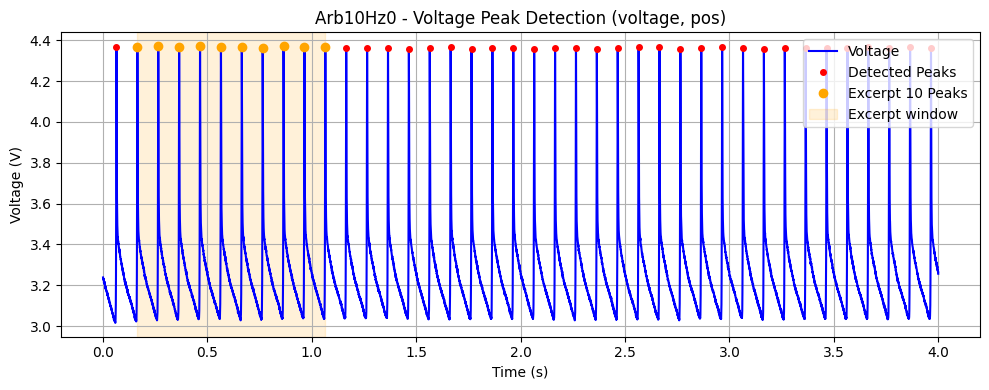

Arb10Hz1_Peak value: 3.98 V
Arb10Hz1_Peak number: 39개
Arb10Hz1_표준편차: 0.00 V
Arb10Hz1_주파수: 10.00 Hz
👉 Arb10Hz1 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 39.80 V
   - 발췌 평균 Peak value: 3.98 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 10.00 Hz


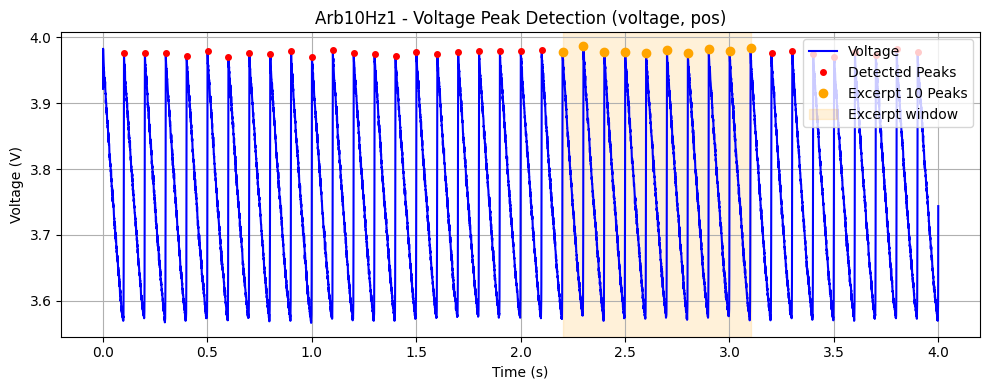

Arb1Hz0_Peak value: 4.37 V
Arb1Hz0_Peak number: 4개
Arb1Hz0_표준편차: 0.00 V
Arb1Hz0_주파수: 1.00 Hz


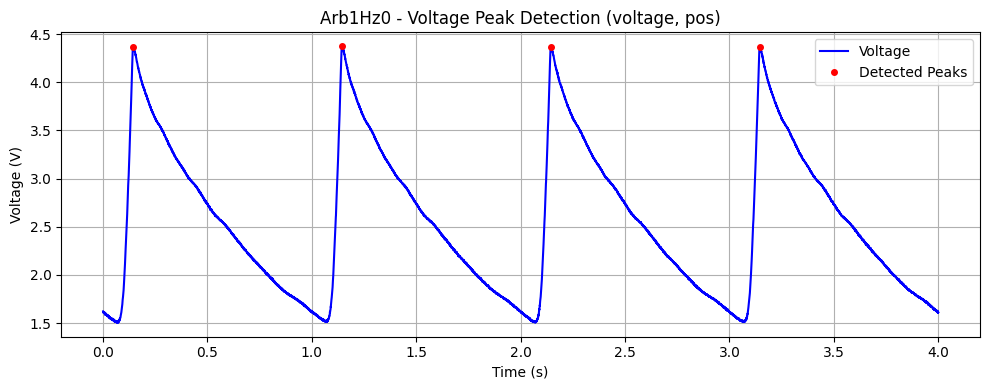

Arb1Hz1_Peak value: 4.77 V
Arb1Hz1_Peak number: 4개
Arb1Hz1_표준편차: 0.00 V
Arb1Hz1_주파수: 1.00 Hz


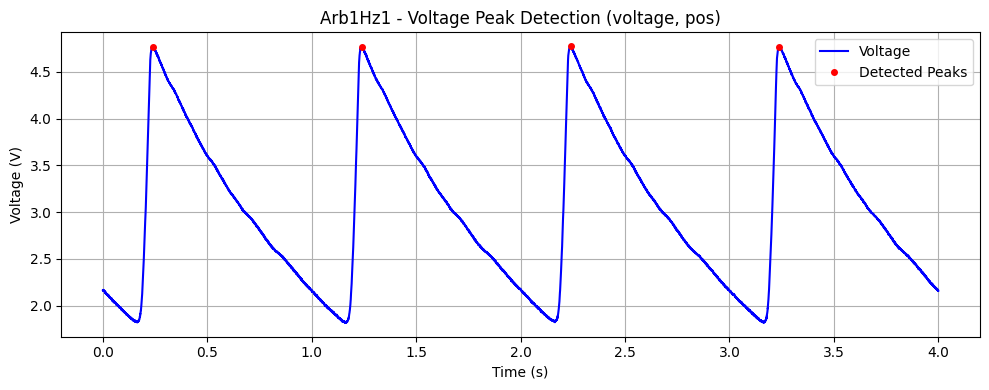

Arb4Hz0_Peak value: 4.07 V
Arb4Hz0_Peak number: 16개
Arb4Hz0_표준편차: 0.01 V
Arb4Hz0_주파수: 4.00 Hz
👉 Arb4Hz0 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 40.79 V
   - 발췌 평균 Peak value: 4.08 V (표준편차: 0.01 V)
   - 발췌 평균 주파수: 4.00 Hz


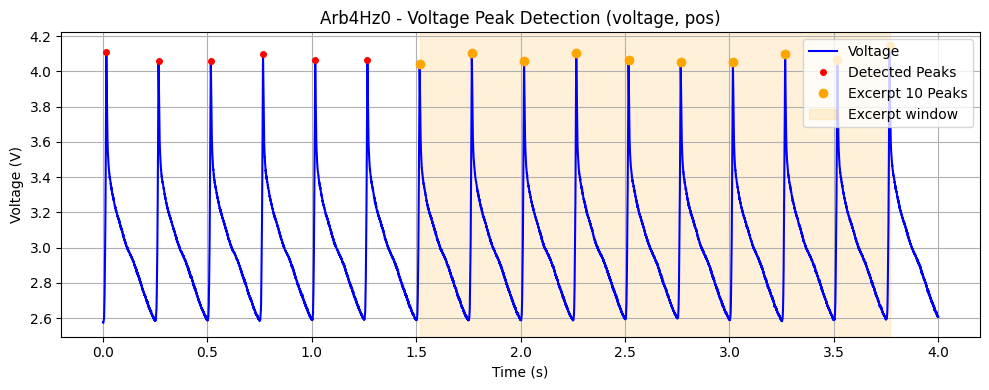

Arb4Hz1_Peak value: 4.19 V
Arb4Hz1_Peak number: 16개
Arb4Hz1_표준편차: 0.00 V
Arb4Hz1_주파수: 4.00 Hz
👉 Arb4Hz1 발췌(연속 10개) 정보
   - 합계(피크 크기 합): 41.95 V
   - 발췌 평균 Peak value: 4.19 V (표준편차: 0.00 V)
   - 발췌 평균 주파수: 4.00 Hz


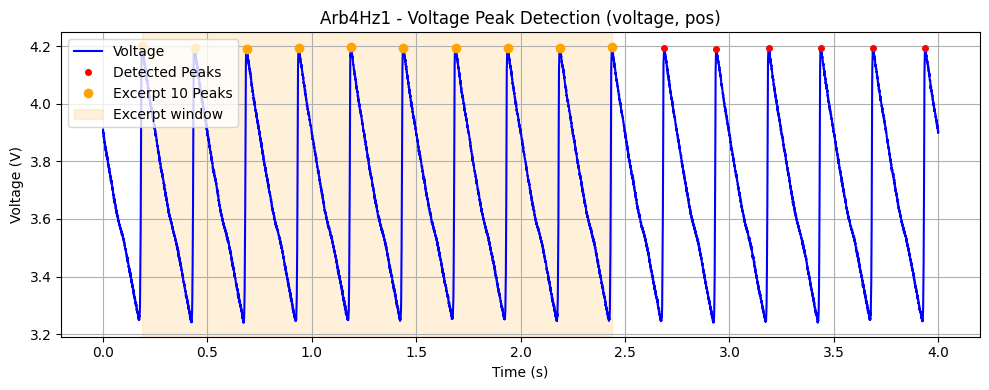


📊 모든 파일 전체 분석 결과 요약 (voltage, peak_mode=pos)
0.1Hz0.csv | Peak value: 5.96 V | 표준편차: 0.00 V | 주파수: 0.00 Hz | 피크 수: 1개
0.1Hz1.csv | Peak value: 5.97 V | 표준편차: 0.00 V | 주파수: 0.00 Hz | 피크 수: 1개
10Hz0.csv | Peak value: 4.97 V | 표준편차: 0.00 V | 주파수: 10.00 Hz | 피크 수: 39개
10Hz1.csv | Peak value: 4.97 V | 표준편차: 0.00 V | 주파수: 10.00 Hz | 피크 수: 40개
1Hz0.csv | Peak value: 5.53 V | 표준편차: 0.00 V | 주파수: 1.00 Hz | 피크 수: 4개
1Hz1.csv | Peak value: 5.63 V | 표준편차: 0.00 V | 주파수: 1.00 Hz | 피크 수: 4개
4Hz0.csv | Peak value: 5.10 V | 표준편차: 0.00 V | 주파수: 4.00 Hz | 피크 수: 16개
4Hz1.csv | Peak value: 5.18 V | 표준편차: 0.00 V | 주파수: 4.00 Hz | 피크 수: 16개
AC-Arb.csv | Peak value: 9.79 V | 표준편차: 0.00 V | 주파수: 4.00 Hz | 피크 수: 16개
AC-Sin.csv | Peak value: 9.99 V | 표준편차: 0.00 V | 주파수: 4.00 Hz | 피크 수: 40개
Arb10Hz0.csv | Peak value: 4.36 V | 표준편차: 0.00 V | 주파수: 10.00 Hz | 피크 수: 40개
Arb10Hz1.csv | Peak value: 3.98 V | 표준편차: 0.00 V | 주파수: 10.00 Hz | 피크 수: 39개
Arb1Hz0.csv | Peak value: 4.37 V | 표준편차: 0.00 V | 주파수: 1.00 Hz | 피크 수: 4

In [9]:
if detection_mode not in {"voltage", "current"}:
    raise ValueError("detection_mode는 'voltage' 또는 'current' 여야 합니다.")

if peak_mode not in {"neg", "pos", "both"}:
    raise ValueError("peak_mode는 'neg', 'pos', 'both' 중 하나여야 합니다.")

signal_label = "Voltage" if detection_mode == "voltage" else "Current"
unit = "V" if detection_mode == "voltage" else "μA"

if detection_mode == "voltage":
    analysis_unit = "Vpp" if peak_mode == "both" else "Peak value"
    csv_skiprows = voltage_skiprows
else:
    analysis_unit = "Ipp" if peak_mode == "both" else "Peak value"
    csv_skiprows = current_skiprows

def calculate_mean_frequency(peak_indices, time_values):
    if len(peak_indices) < 2:
        return 0.0
    peak_times = time_values[peak_indices]
    periods = np.diff(peak_times)
    periods = periods[periods > 0]
    if len(periods) == 0:
        return 0.0
    return float(np.mean(1.0 / periods))

def calc_pair_analysis(signal_values, peak_indices, mode):
    analysis_values = []
    for i in range(len(peak_indices) - 1):
        s = peak_indices[i]
        e = peak_indices[i + 1]
        if mode == "both":
            analysis_val = np.max(signal_values[s:e + 1]) - np.min(signal_values[s:e + 1])
        else:
            mag_i = np.abs(signal_values[peak_indices[i]])
            mag_j = np.abs(signal_values[peak_indices[i + 1]])
            analysis_val = (mag_i + mag_j) / 2.0
        analysis_values.append(float(analysis_val))
    return analysis_values

def load_signal(file_path, mode, skiprows_count, current_conv):
    df = pd.read_csv(file_path, skiprows=skiprows_count)
    time_values = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy()
    signal_values = pd.to_numeric(df.iloc[:, 1], errors="coerce").to_numpy()
    if mode == "current":
        signal_values = signal_values * current_conv

    valid = np.isfinite(time_values) & np.isfinite(signal_values)
    time_values = time_values[valid]
    signal_values = signal_values[valid]

    if len(time_values) < 3:
        raise ValueError("유효한 데이터 포인트가 너무 적습니다.")

    return time_values.astype(float), signal_values.astype(float)

def detect_filtered_peaks(signal_values, time_values, mode):
    total_time = time_values[-1] - time_values[0]
    if total_time <= 0:
        raise ValueError("시간 데이터가 올바르지 않습니다.")

    sampling_rate = len(time_values) / total_time
    distance = max(1, int(sampling_rate * min_distance_sec))
    prom = max(np.std(signal_values) * prominence_ratio, min_prominence)

    if mode == "neg":
        raw_peaks, _ = find_peaks(-signal_values, prominence=prom, distance=distance)
    elif mode == "pos":
        raw_peaks, _ = find_peaks(signal_values, prominence=prom, distance=distance)
    else:
        raw_pos, _ = find_peaks(signal_values, prominence=prom, distance=distance)
        raw_neg, _ = find_peaks(-signal_values, prominence=prom, distance=distance)
        raw_peaks = np.sort(np.concatenate([raw_pos, raw_neg]))

    max_amplitude = float(np.max(np.abs(signal_values))) if len(signal_values) else 0.0
    window = max(1, int(0.05 * sampling_rate))
    final_peaks = []

    for idx in raw_peaks:
        left = max(0, idx - window)
        right = min(len(signal_values), idx + window)
        local_noise = max(float(np.std(signal_values[left:right])), 1e-12)
        signal_mag = float(np.abs(signal_values[idx]))

        if (
            signal_mag > max_amplitude * min_relative_height
            and (signal_mag / local_noise) > snr_threshold
            and signal_mag > abs_min_height
        ):
            final_peaks.append(int(idx))

    return np.array(final_peaks, dtype=int), sampling_rate, prom

csv_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(".csv")])

summary_rows = []
excerpt_summary_rows = []

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    base_name = os.path.splitext(file_name)[0]

    try:
        time_values, signal_values = load_signal(file_path, detection_mode, csv_skiprows, current_scale)
        final_peaks, sampling_rate, prom = detect_filtered_peaks(signal_values, time_values, peak_mode)

        analysis_list = calc_pair_analysis(signal_values, final_peaks, peak_mode)

        if len(final_peaks) >= 2:
            mean_analysis = float(np.mean(analysis_list)) if analysis_list else 0.0
            std_analysis = float(np.std(analysis_list, ddof=1)) if len(analysis_list) > 1 else 0.0
        elif len(final_peaks) == 1:
            mean_analysis = float(np.abs(signal_values[final_peaks[0]]))
            std_analysis = 0.0
        else:
            mean_analysis = 0.0
            std_analysis = 0.0

        mean_freq = calculate_mean_frequency(final_peaks, time_values)

        print(f"{base_name}_{analysis_unit}: {mean_analysis:.2f} {unit}")
        print(f"{base_name}_Peak number: {len(final_peaks):.0f}개")
        print(f"{base_name}_표준편차: {std_analysis:.2f} {unit}")
        print(f"{base_name}_주파수: {mean_freq:.2f} Hz")

        summary_rows.append({
            "File": file_name,
            analysis_unit: mean_analysis,
            "Std": std_analysis,
            "Freq": mean_freq,
            "Peak_Count": int(len(final_peaks))
        })

        excerpt_idx = None
        excerpt_mean_analysis = None
        excerpt_std_analysis = None
        excerpt_mean_freq = None

        if len(final_peaks) >= window_peaks:
            peak_values = signal_values[final_peaks].astype(float)
            peak_mags = np.abs(peak_values)

            csum = np.cumsum(peak_mags)
            sums = csum[window_peaks - 1:] - np.concatenate(([0.0], csum[:-window_peaks]))
            best_start = int(np.argmax(sums))
            best_end = best_start + window_peaks

            excerpt_idx = final_peaks[best_start:best_end]
            excerpt_analysis = calc_pair_analysis(signal_values, excerpt_idx, peak_mode)

            if len(excerpt_idx) >= 2:
                excerpt_mean_analysis = float(np.mean(excerpt_analysis)) if excerpt_analysis else 0.0
                excerpt_std_analysis = float(np.std(excerpt_analysis, ddof=1)) if len(excerpt_analysis) > 1 else 0.0
            else:
                excerpt_mean_analysis = float(np.abs(signal_values[excerpt_idx[0]]))
                excerpt_std_analysis = 0.0

            excerpt_mean_freq = calculate_mean_frequency(excerpt_idx, time_values)

            print(f"👉 {base_name} 발췌(연속 {window_peaks}개) 정보")
            print(f"   - 합계(피크 크기 합): {np.sum(np.abs(signal_values[excerpt_idx])):.2f} {unit}")
            print(f"   - 발췌 평균 {analysis_unit}: {excerpt_mean_analysis:.2f} {unit} (표준편차: {excerpt_std_analysis:.2f} {unit})")
            print(f"   - 발췌 평균 주파수: {excerpt_mean_freq:.2f} Hz")

            excerpt_summary_rows.append({
                "File": file_name,
                analysis_unit: excerpt_mean_analysis,
                "Std": excerpt_std_analysis,
                "Freq": excerpt_mean_freq,
                "Peak_Count": int(len(excerpt_idx)),
                "Peak_Sum": float(np.sum(np.abs(signal_values[excerpt_idx])))
            })

        plt.figure(figsize=(10, 4))
        line_color = "blue" if detection_mode == "voltage" else "gray"
        plt.plot(time_values, signal_values, color=line_color, label=signal_label)
        if len(final_peaks) > 0:
            plt.plot(time_values[final_peaks], signal_values[final_peaks], "o", ms=4, color="red", label="Detected Peaks")
        if excerpt_idx is not None and len(excerpt_idx) > 0:
            plt.plot(time_values[excerpt_idx], signal_values[excerpt_idx], "o", ms=6, color="orange", label=f"Excerpt {window_peaks} Peaks")
            plt.axvspan(time_values[excerpt_idx[0]], time_values[excerpt_idx[-1]], alpha=0.15, color="orange", label="Excerpt window")

        plt.title(f"{base_name} - {signal_label} Peak Detection ({detection_mode}, {peak_mode})")
        plt.xlabel("Time (s)")
        plt.ylabel(f"{signal_label} ({unit})")
        plt.ylim(y_range)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ {file_name} 처리 중 오류 발생: {e}")

print("\n==============================")
print(f"📊 모든 파일 전체 분석 결과 요약 ({detection_mode}, peak_mode={peak_mode})")

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    for _, row in summary_df.iterrows():
        print(
            f"{row['File']} | {analysis_unit}: {row[analysis_unit]:.2f} {unit} | "
            f"표준편차: {row['Std']:.2f} {unit} | 주파수: {row['Freq']:.2f} Hz | 피크 수: {int(row['Peak_Count'])}개"
        )

    overall_mean_analysis = float(summary_df[analysis_unit].mean())
    overall_mean_std = float(summary_df['Std'].mean())
    overall_mean_freq = float(summary_df['Freq'].mean())

    print("\n==============================")
    print(f"📈 전체 평균 {analysis_unit}: {overall_mean_analysis:.2f} {unit}")
    print(f"📉 평균 표준편차: {overall_mean_std:.2f} {unit}")
    print(f"🎵 전체 평균 주파수: {overall_mean_freq:.2f} Hz")
else:
    print("📭 전체 분석 결과를 계산할 수 없습니다.")

print("\n==============================")
print(f"🎯 모든 파일 발췌 결과 요약 (연속 {window_peaks}개 피크 기준)")

if excerpt_summary_rows:
    excerpt_df = pd.DataFrame(excerpt_summary_rows)
    for _, row in excerpt_df.iterrows():
        print(
            f"{row['File']} | {analysis_unit}: {row[analysis_unit]:.2f} {unit} | "
            f"표준편차: {row['Std']:.2f} {unit} | 주파수: {row['Freq']:.2f} Hz | 피크 수: {int(row['Peak_Count'])}개"
        )

    excerpt_avg_analysis = float(excerpt_df[analysis_unit].mean())
    excerpt_avg_std = float(excerpt_df['Std'].mean())
    excerpt_avg_freq = float(excerpt_df['Freq'].mean())

    print("\n==============================")
    print(f"📊 전체 평균 {analysis_unit}: {excerpt_avg_analysis:.2f} {unit}")
    print(f"📉 평균 표준편차: {excerpt_avg_std:.2f} {unit}")
    print(f"🎵 평균 주파수: {excerpt_avg_freq:.2f} Hz")
else:
    print("📭 발췌 가능한 파일이 없거나 피크 수가 부족합니다.")

if save_summary_csv:
    if summary_rows:
        summary_output = os.path.join(folder_path, f"00summary_full_{detection_mode}_{peak_mode}.csv")
        summary_df.to_csv(summary_output, index=False, encoding="utf-8-sig")
        print(f"✅ 전체 요약 CSV 저장 완료: {summary_output}")

    if excerpt_summary_rows:
        excerpt_output = os.path.join(folder_path, f"00summary_excerpt_{detection_mode}_{peak_mode}_{window_peaks}peaks.csv")
        excerpt_df.to_csv(excerpt_output, index=False, encoding="utf-8-sig")
        print(f"✅ 발췌 요약 CSV 저장 완료: {excerpt_output}")
